In [1]:
# %pip install numpy-financial shap
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm 

In [2]:
# !pip install numpy-financial shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy_financial as npf
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    precision_recall_curve
)

/Users/himanshmac/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# from google.colab import files
# uploaded = files.upload()

In [4]:
df = pd.read_csv("../data/corporate_projects-1.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n")
print(df.dtypes)

print("\nMissing values:\n")
print(df.isnull().sum())

print("\nSuccess distribution:\n")
print(df["Success"].value_counts())
print(df["Success"].value_counts(normalize=True))

In [5]:
df.describe(include="all")


,Project_ID,Department,Investment_Cost,Expected_Cashflow_Year1,Expected_Cashflow_Year2,Expected_Cashflow_Year3,Historical_ROI,Market_Growth,Project_Risk,Success
count,50.00000,50,5.000000e+01,5.000000e+01,5.000000e+01,5.000000e+01,50.000000,50.000000,50,50.000000
unique,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,Marketing,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,16,NaN,NaN,NaN,NaN,NaN,NaN,20,NaN
mean,25.50000,NaN,2.508812e+06,1.019832e+06,1.245896e+06,1.513842e+06,0.165600,0.052400,NaN,0.520000
std,14.57738,NaN,1.250287e+06,5.953064e+05,7.558611e+05,8.965712e+05,0.058699,0.053167,NaN,0.504672
min,1.00000,NaN,1.232470e+05,6.266600e+04,7.195900e+04,8.935300e+04,0.050000,-0.040000,NaN,0.000000
25%,13.25000,NaN,1.731652e+06,5.329580e+05,5.431870e+05,8.166712e+05,0.112500,0.010000,NaN,0.000000
50%,25.50000,NaN,2.685838e+06,1.037420e+06,1.254198e+06,1.538296e+06,0.165000,0.050000,NaN,1.000000
75%,37.75000,NaN,3.480671e+06,1.475176e+06,1.993304e+06,2.263428e+06,0.220000,0.087500,NaN,1.000000


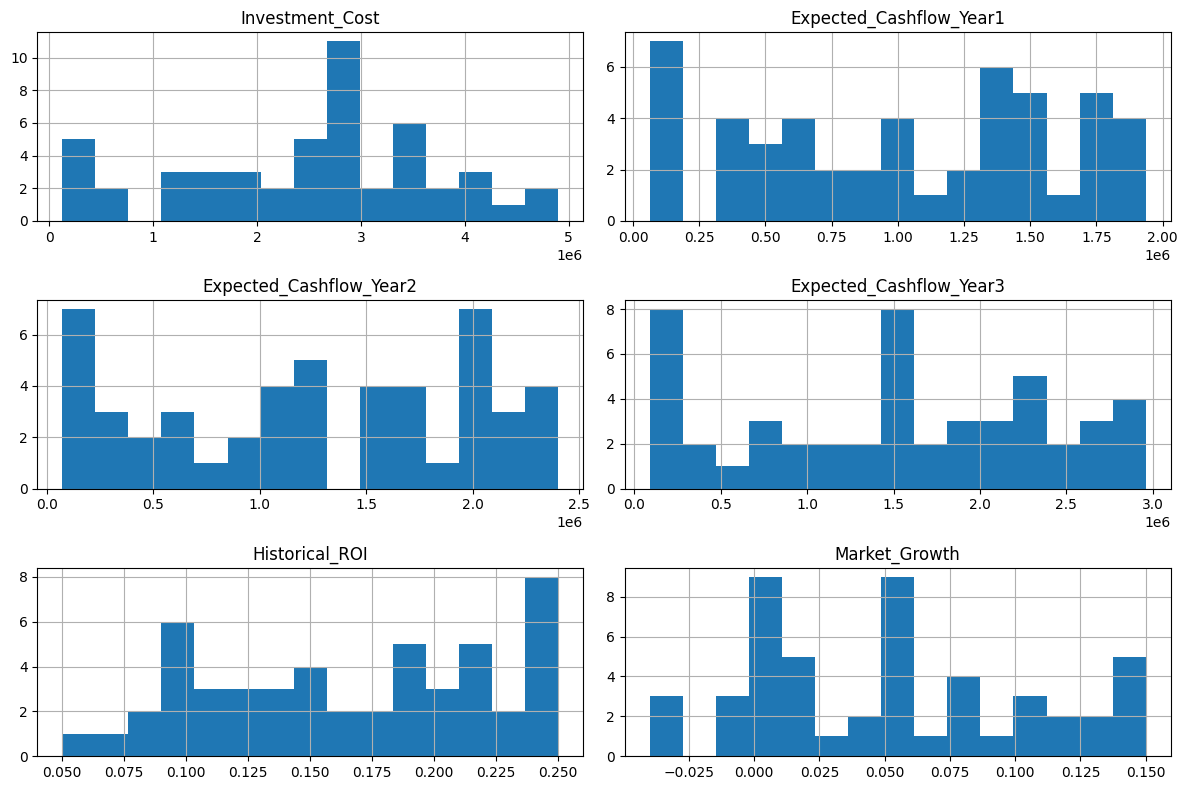

In [6]:
# EDA
num_cols = [
    "Investment_Cost",
    "Expected_Cashflow_Year1",
    "Expected_Cashflow_Year2",
    "Expected_Cashflow_Year3",
    "Historical_ROI",
    "Market_Growth"
]

df[num_cols].hist(figsize=(12, 8), bins=15)
plt.tight_layout()
plt.show()

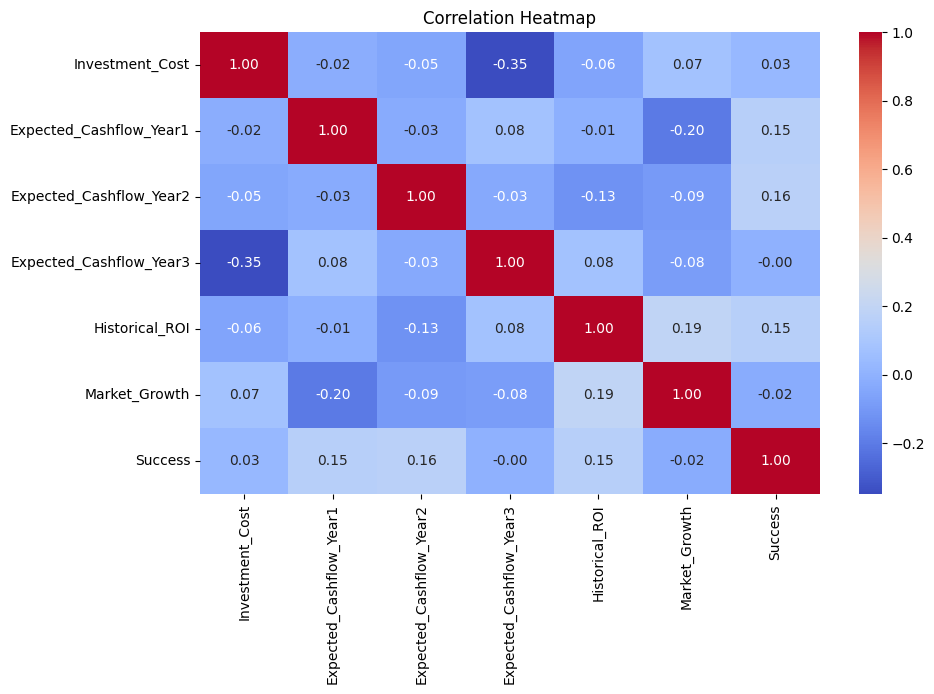

In [7]:
# correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols + ["Success"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

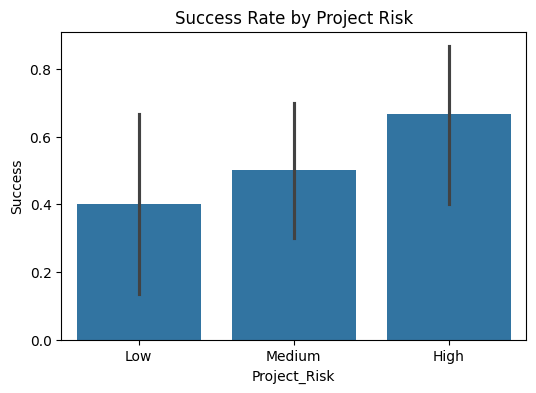

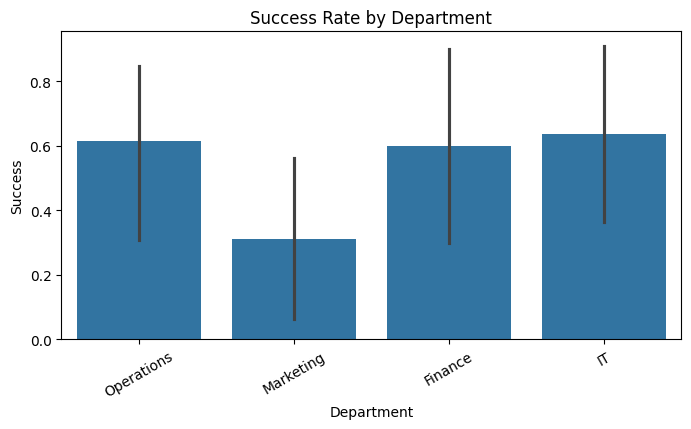

In [8]:
# Success by risk and department
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="Project_Risk", y="Success", order=["Low", "Medium", "High"])
plt.title("Success Rate by Project Risk")
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="Department", y="Success")
plt.title("Success Rate by Department")
plt.xticks(rotation=30)
plt.show()

  CASH FLOW FORECASTING — RandomForestRegressor

Expected_Cashflow_Year1
  MAE : 307,271
  R²  : 0.613

Expected_Cashflow_Year2
  MAE : 449,728
  R²  : 0.506

Expected_Cashflow_Year3
  MAE : 450,718
  R²  : 0.637


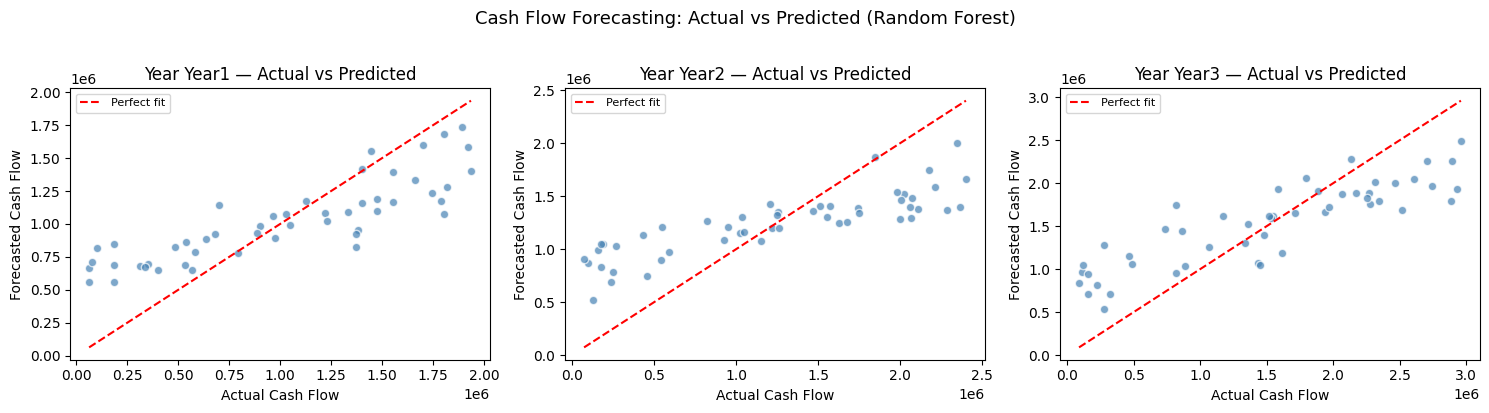

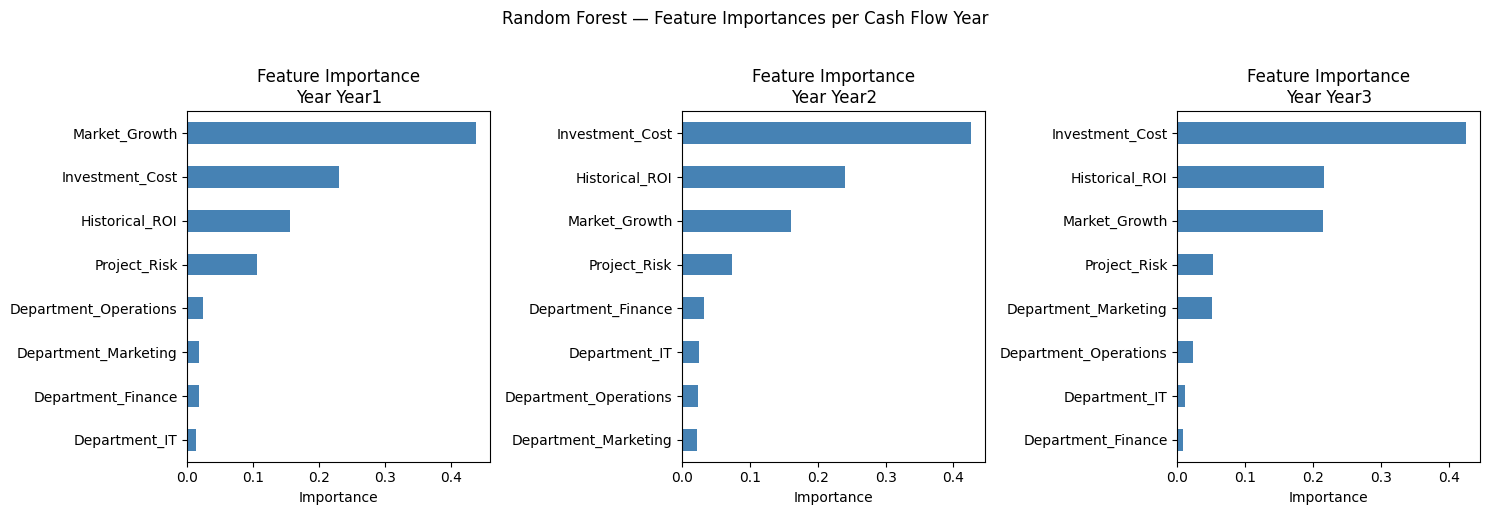


 Forecasted cash flows saved to df['Forecasted_CF_Year1/2/3']
   These can be used in place of raw inputs to compute a forecasted NPV.


In [9]:

# Cash Flow Forecasting using Random Forest Regressor
# Predicts Year 1, 2, and 3 cash flows from project features

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")

# define regression features and targets
reg_features = [
    "Investment_Cost",
    "Historical_ROI",
    "Market_Growth",
    "Department",
    "Project_Risk"
]

cf_targets = [
    "Expected_Cashflow_Year1",
    "Expected_Cashflow_Year2",
    "Expected_Cashflow_Year3"
]

X_reg = df[reg_features].copy()
y_reg = df[cf_targets].copy()

# Preprocessing for regression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

reg_numeric     = ["Investment_Cost", "Historical_ROI", "Market_Growth"]
reg_cat_onehot  = ["Department"]
reg_cat_ordinal = ["Project_Risk"]

reg_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ]), reg_numeric),

    ("cat_oh", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), reg_cat_onehot),

    ("cat_ord", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(categories=[["Low", "Medium", "High"]]))
    ]), reg_cat_ordinal)
])

# Multi-output Random Forest pipeline
rf_reg_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor",    MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=200,
            max_depth=4,
            min_samples_leaf=2,
            random_state=42
        )
    ))
])

# Train on full dataset (n=50)
rf_reg_pipeline.fit(X_reg, y_reg)
y_pred_cf = rf_reg_pipeline.predict(X_reg)

# In-sample metrics per year
print("=" * 55)
print("  CASH FLOW FORECASTING — RandomForestRegressor")
print("=" * 55)

for i, col in enumerate(cf_targets):
    mae = mean_absolute_error(y_reg[col], y_pred_cf[:, i])
    r2  = r2_score(y_reg[col], y_pred_cf[:, i])
    print(f"\n{col}")
    print(f"  MAE : {mae:,.0f}")
    print(f"  R²  : {r2:.3f}")

# Storing forecasted cash flows
df["Forecasted_CF_Year1"] = y_pred_cf[:, 0]
df["Forecasted_CF_Year2"] = y_pred_cf[:, 1]
df["Forecasted_CF_Year3"] = y_pred_cf[:, 2]

# Visualise: Actual vs Forecasted for each year
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (col, ax) in enumerate(zip(cf_targets, axes)):
    ax.scatter(y_reg[col], y_pred_cf[:, i], alpha=0.7, color="steelblue", edgecolors="white")
    mn = min(y_reg[col].min(), y_pred_cf[:, i].min())
    mx = max(y_reg[col].max(), y_pred_cf[:, i].max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect fit")
    ax.set_title(f"{col.replace('Expected_Cashflow_', 'Year ')} — Actual vs Predicted")
    ax.set_xlabel("Actual Cash Flow")
    ax.set_ylabel("Forecasted Cash Flow")
    ax.legend(fontsize=8)

plt.suptitle("Cash Flow Forecasting: Actual vs Predicted (Random Forest)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Feature importance per target year
feature_names_reg = (
    reg_numeric
    + list(rf_reg_pipeline.named_steps["preprocessor"]
           .named_transformers_["cat_oh"]
           .named_steps["onehot"]
           .get_feature_names_out(reg_cat_onehot))
    + reg_cat_ordinal
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (col, ax) in enumerate(zip(cf_targets, axes)):
    estimator = rf_reg_pipeline.named_steps["regressor"].estimators_[i]
    importances = pd.Series(estimator.feature_importances_, index=feature_names_reg)
    importances.sort_values(ascending=True).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Feature Importance\n{col.replace('Expected_Cashflow_', 'Year ')}")
    ax.set_xlabel("Importance")

plt.suptitle("Random Forest — Feature Importances per Cash Flow Year", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("\n Forecasted cash flows saved to df['Forecasted_CF_Year1/2/3']")
print("   These can be used in place of raw inputs to compute a forecasted NPV.")

In [10]:
# NPV calcuation assuming discount rate of 10%
discount_rate = 0.10

df["NPV"] = (
    df["Expected_Cashflow_Year1"] / (1 + discount_rate)**1 +
    df["Expected_Cashflow_Year2"] / (1 + discount_rate)**2 +
    df["Expected_Cashflow_Year3"] / (1 + discount_rate)**3 -
    df["Investment_Cost"]
)

df["Total_Expected_Cashflow"] = (
    df["Expected_Cashflow_Year1"] +
    df["Expected_Cashflow_Year2"] +
    df["Expected_Cashflow_Year3"]
)

df["Cashflow_to_Investment"] = df["Total_Expected_Cashflow"] / df["Investment_Cost"]
df["Year1_Cashflow_to_Investment"] = df["Expected_Cashflow_Year1"] / df["Investment_Cost"]

df["NPV_to_Investment"] = df["NPV"] / df["Investment_Cost"]

df[[
    "Project_ID",
    "Investment_Cost",
    "NPV",
    "Total_Expected_Cashflow",
    "Cashflow_to_Investment",
    "NPV_to_Investment"
]].head()

,Project_ID,Investment_Cost,NPV,Total_Expected_Cashflow,Cashflow_to_Investment,NPV_to_Investment
0,1,184654,3.706072e+06,4821128,26.108982,20.070359
1,2,2054354,-8.182127e+04,2267337,1.103674,-0.039828
2,3,2516182,2.121152e+06,5684155,2.259040,0.843004
3,4,3574675,-6.883530e+05,3441072,0.962625,-0.192564
4,5,2752991,-6.509728e+05,2474327,0.898778,-0.236460


In [11]:
risk_map = {"Low": 1, "Medium": 2, "High": 3}
df["Risk_Score_Num"] = df["Project_Risk"].map(risk_map)

df["Risk_Adjusted_ROI"] = df["Historical_ROI"] / df["Risk_Score_Num"]

In [12]:
# features and targets - since NPV is calculated from Cf1,CF2,CF3, eliminating these three from feature sets along with total expected cash flow. additionally creating two models one with and one without NPV
target = "Success"

feature_cols_with_npv = [
    "Department",
    "Investment_Cost",
    "NPV",
    "NPV_to_Investment",
    "Cashflow_to_Investment",
    "Historical_ROI",
    "Market_Growth",
    "Project_Risk",
    "Risk_Adjusted_ROI"
]

feature_cols_without_npv = [
    "Department",
    "Investment_Cost",
    "Cashflow_to_Investment",
    "Historical_ROI",
    "Market_Growth",
    "Project_Risk",
    "Risk_Adjusted_ROI"
]

# choose one for modeling
feature_cols = feature_cols_with_npv

X = df[feature_cols].copy()
y = df[target].copy()


In [13]:
categorical_onehot = ["Department"]
categorical_ordinal = ["Project_Risk"]

numeric_features = [col for col in feature_cols if col not in categorical_onehot + categorical_ordinal]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

categorical_ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[["Low", "Medium", "High"]]))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat_oh", categorical_onehot_transformer, categorical_onehot),
    ("cat_ord", categorical_ordinal_transformer, categorical_ordinal)
])

In [14]:
# Train test split..stratify on Success as dataset is small
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain success distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest success distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (40, 9)
Test shape: (10, 9)

Train success distribution:
Success
1    0.525
0    0.475
Name: proportion, dtype: float64

Test success distribution:
Success
0    0.5
1    0.5
Name: proportion, dtype: float64


In [15]:
# logistic regression model
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_log, zero_division=0))
print("F1:", f1_score(y_test, y_pred_log, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log, zero_division=0))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.6
Precision: 0.6
Recall: 0.6
F1: 0.6
ROC-AUC: 0.52

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10



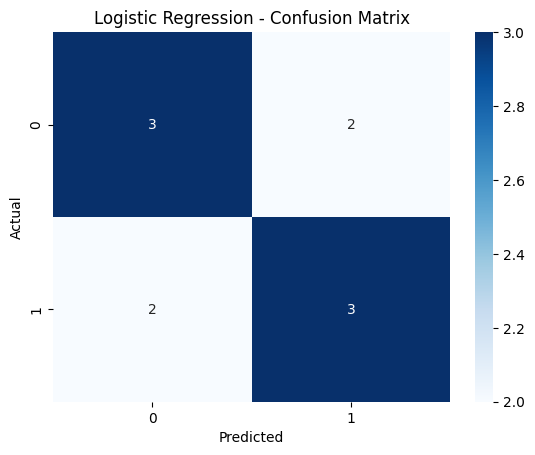

In [16]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

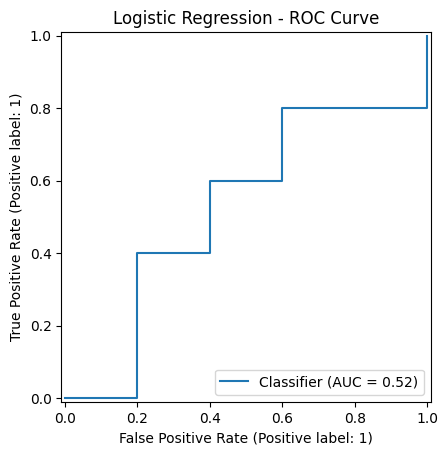

In [17]:
# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_log)
plt.title("Logistic Regression - ROC Curve")
plt.show()

In [18]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=2,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1:", f1_score(y_test, y_pred_rf, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

RANDOM FOREST RESULTS
Accuracy: 0.6
Precision: 0.6
Recall: 0.6
F1: 0.6
ROC-AUC: 0.64

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10



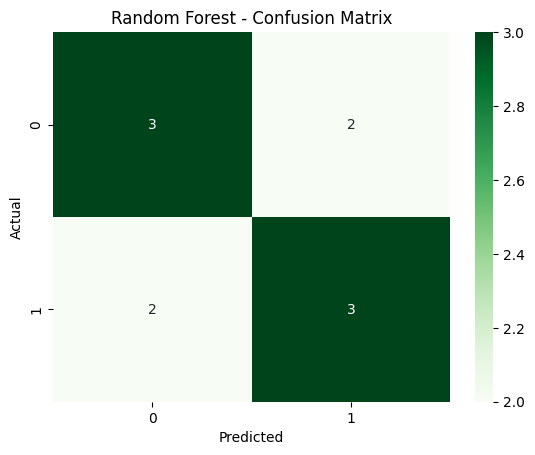

In [19]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

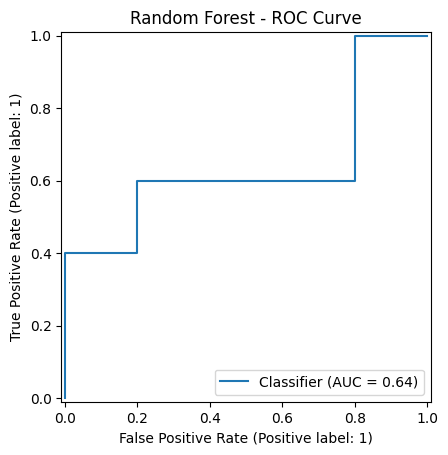

In [20]:
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("Random Forest - ROC Curve")
plt.show()

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_feature_set(feature_list):
    X_temp = df[feature_list].copy()

    categorical_onehot = ["Department"]
    categorical_ordinal = ["Project_Risk"]
    numeric_features = [col for col in feature_list if col not in categorical_onehot + categorical_ordinal]

    preprocessor_temp = ColumnTransformer(transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat_oh", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_onehot),
        ("cat_ord", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(categories=[["Low", "Medium", "High"]]))
        ]), categorical_ordinal)
    ])

    model_temp = Pipeline(steps=[
        ("preprocessor", preprocessor_temp),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ])

    scores = cross_val_score(model_temp, X_temp, y, cv=cv, scoring="roc_auc")
    return scores

scores_with_npv = evaluate_feature_set(feature_cols_with_npv)
scores_without_npv = evaluate_feature_set(feature_cols_without_npv)

print("WITH NPV ROC-AUC:", scores_with_npv)
print("WITH NPV Mean:", scores_with_npv.mean())

print("\nWITHOUT NPV ROC-AUC:", scores_without_npv)
print("WITHOUT NPV Mean:", scores_without_npv.mean())

WITH NPV ROC-AUC: [0.64  0.4   0.48  0.56  0.375]
WITH NPV Mean: 0.491

WITHOUT NPV ROC-AUC: [0.8  0.36 0.4  0.44 0.5 ]
WITHOUT NPV Mean: 0.5


In [22]:
# cross validation comparision
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_cv_auc = cross_val_score(log_model, X, y, cv=cv, scoring="roc_auc")
rf_cv_auc = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc")

print("Logistic Regression CV ROC-AUC:", log_cv_auc)
print("Mean:", log_cv_auc.mean())

print("\nRandom Forest CV ROC-AUC:", rf_cv_auc)
print("Mean:", rf_cv_auc.mean())

Logistic Regression CV ROC-AUC: [0.64  0.4   0.48  0.56  0.375]
Mean: 0.491

Random Forest CV ROC-AUC: [0.72 0.4  0.64 0.56 0.25]
Mean: 0.514


### Model Performance Note

The model performance (ROC-AUC ~0.5–0.55) indicates limited predictive power probably due to the small dataset (~50 observations).

Therefore, the model is used as a support tool for decision making and not as a predictor

The primary value of the framework lies in combining ML-based probability with financial metrics (NPV, Expected Value) for capital allocation.

In [23]:
df["Success"].value_counts(normalize=True)

Success
1    0.52
0    0.48
Name: proportion, dtype: float64

In [24]:
final_model = log_model
final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Investment_Cost', 'NPV',
                                                   'NPV_to_Investment',
                                                   'Cashflow_to_Investment',
                                                   'Historical_ROI',
                                                   'Market_Growth',
                                                   'Risk_Adjusted_ROI']),
                                                 ('cat_oh',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Department']),
                                                 ('cat_ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High']]))]),
                                                  ['Project_Risk'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [25]:
# scoring all projects
df["Predicted_Success_Prob"] = final_model.predict_proba(X)[:, 1]
df["Predicted_Success_Class"] = final_model.predict(X)

df[["Project_ID", "Predicted_Success_Prob", "Predicted_Success_Class"]].head()

,Project_ID,Predicted_Success_Prob,Predicted_Success_Class
0,1,0.398981,0
1,2,0.224365,0
2,3,0.777578,1
3,4,0.639305,1
4,5,0.578412,1


In [26]:
risk_map = {"Low": 1.0, "Medium": 1.5, "High": 2.0}
df["Risk_Score"] = df["Project_Risk"].map(risk_map)

df["Expected_Value"] = df["NPV"] * df["Predicted_Success_Prob"]
df["Risk_Adjusted_EV"] = df["Expected_Value"] / df["Risk_Score"]
df["Expected_Value_to_Investment"] = df["Expected_Value"] / df["Investment_Cost"]

In [27]:
def compute_irr(row):
    """
    Compute IRR from investment and expected 3-year cash flows.
    Returns np.nan if IRR cannot be solved.
    """
    cash_flows = [
        -row["Investment_Cost"],
        row["Expected_Cashflow_Year1"],
        row["Expected_Cashflow_Year2"],
        row["Expected_Cashflow_Year3"]
    ]

    pos = any(c > 0 for c in cash_flows)
    neg = any(c < 0 for c in cash_flows)
    if not (pos and neg):
        return np.nan

    try:
        return npf.irr(cash_flows)
    except Exception:
        return np.nan

df["IRR"] = df.apply(compute_irr, axis=1)

In [28]:
# Move to bottom: Forecasted ROI calculation
df['Total_Forecasted_Cashflow'] = df['Forecasted_CF_Year1'] + df['Forecasted_CF_Year2'] + df['Forecasted_CF_Year3']
df['Forecasted_ROI'] = (df['Total_Forecasted_Cashflow'] - df['Investment_Cost']) / df['Investment_Cost']

print("Projects with new Forecasted ROI calculation:")
display(df[['Project_ID', 'Investment_Cost', 'Historical_ROI', 'Forecasted_ROI']].head())

Projects with new Forecasted ROI calculation:


,Project_ID,Investment_Cost,Historical_ROI,Forecasted_ROI
0,1,184654,0.08,24.437645
1,2,2054354,0.15,0.817627
2,3,2516182,0.19,0.638722
3,4,3574675,0.22,-0.048785
4,5,2752991,0.12,0.141152


In [29]:
# Move to bottom: Payback Period calculation
def calculate_payback_period(investment, cashflows):
    remaining_investment = investment
    payback_year = 0
    for i, cf in enumerate(cashflows):
        if remaining_investment <= 0: break
        if cf <= 0:
            payback_year += 1
            continue
        remaining_investment -= cf
        payback_year += 1
    if remaining_investment <= 0:
        if cashflows[-1] > 0 and remaining_investment < 0:
            amount_needed_at_start_of_last_year = investment - sum(cashflows[:payback_year-1])
            fraction = amount_needed_at_start_of_last_year / cashflows[payback_year - 1]
            return (payback_year - 1) + fraction
        return payback_year
    return np.inf

df['Expected_Payback_Period'] = df.apply(lambda row: calculate_payback_period(row['Investment_Cost'], [row['Expected_Cashflow_Year1'], row['Expected_Cashflow_Year2'], row['Expected_Cashflow_Year3']]), axis=1)
df['Forecasted_Payback_Period'] = df.apply(lambda row: calculate_payback_period(row['Investment_Cost'], [row['Forecasted_CF_Year1'], row['Forecasted_CF_Year2'], row['Forecasted_CF_Year3']]), axis=1)

print("Projects with new Payback Period calculations:")
display(df[['Project_ID', 'Investment_Cost', 'Expected_Payback_Period', 'Forecasted_Payback_Period']].head())

Projects with new Payback Period calculations:


,Project_ID,Investment_Cost,Expected_Payback_Period,Forecasted_Payback_Period
0,1,184654,0.316429,0.233964
1,2,2054354,2.235458,1.558327
2,3,2516182,1.572136,2.202830
3,4,3574675,inf,inf
4,5,2752991,inf,2.596689


In [30]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_log)

threshold_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision[:-1],
    "Recall": recall[:-1]
})

threshold_df["F1"] = (
    2 * threshold_df["Precision"] * threshold_df["Recall"]
    / (threshold_df["Precision"] + threshold_df["Recall"]).replace(0, np.nan)
)

threshold_df = threshold_df.sort_values("F1", ascending=False)
threshold_df.head(10)

,Threshold,Precision,Recall,F1
0,0.028397,0.500000,1.0,0.666667
3,0.419980,0.571429,0.8,0.666667
2,0.303635,0.500000,0.8,0.615385
5,0.514097,0.600000,0.6,0.600000
1,0.293073,0.444444,0.8,0.571429
4,0.469190,0.500000,0.6,0.545455
7,0.595999,0.666667,0.4,0.500000
6,0.537419,0.500000,0.4,0.444444
8,0.629840,0.500000,0.2,0.285714
9,0.646774,0.000000,0.0,NaN


In [31]:
SUCCESS_THRESHOLD = 0.65 #
REVIEW_THRESHOLD = 0.50

def recommend(row):
    if row["NPV"] < 0:
        return "Reject"
    elif row["Expected_Value"] <= 0:
        return "Reject"
    elif row["Predicted_Success_Prob"] >= SUCCESS_THRESHOLD:
        return "Fund"
    elif row["Predicted_Success_Prob"] >= REVIEW_THRESHOLD:
        return "Review"
    else:
        return "Reject"

df["Recommendation"] = df.apply(recommend, axis=1)

The success threshold (0.65) is chosen to balance avoiding false positives (funding bad projects) and ensuring sufficient selectivity in capital allocation


In [32]:
recommendation_order = {'Fund': 0, 'Review': 1, 'Reject': 2}
df['Recommendation_Order'] = df['Recommendation'].map(recommendation_order)

# Sorting based on strategic priority and the new ROI metric
ranked_projects = df.sort_values(
    by=['Recommendation_Order', 'Risk_Adjusted_EV', 'Expected_Value', 'Forecasted_ROI'],
    ascending=[True, False, False, False]
).reset_index(drop=True)

ranked_projects['Rank'] = ranked_projects.index + 1

# Defining the columns for the dashboard-ready final table
final_cols = [
    'Rank',
    'Project_ID',
    'Department',
    'Investment_Cost',
    'NPV',
    'Forecasted_ROI',
    'Expected_Payback_Period',
    'Forecasted_Payback_Period',
    'Predicted_Success_Prob',
    'Recommendation'
]

print('FINAL PROJECT RANKING WITH ML-DRIVEN METRICS')
display(ranked_projects[final_cols].head(10))

FINAL PROJECT RANKING WITH ML-DRIVEN METRICS


,Rank,Project_ID,Department,Investment_Cost,NPV,Forecasted_ROI,Expected_Payback_Period,Forecasted_Payback_Period,Predicted_Success_Prob,Recommendation
0,1,43,IT,664685,3.653868e+06,5.467267,0.689572,0.629046,0.721332,Fund
1,2,35,IT,296769,3.690876e+06,15.455687,0.164307,0.176599,0.700555,Fund
2,3,3,Finance,2516182,2.121152e+06,0.638722,1.572136,2.202830,0.777578,Fund
3,4,36,Finance,2758505,1.079105e+06,0.438421,1.667853,2.253448,0.678808,Fund
4,5,40,Operations,3147262,9.859812e+05,0.428543,1.955308,2.343830,0.699798,Fund
5,6,10,IT,2670406,1.077058e+06,0.572890,2.032064,2.078341,0.672996,Fund
6,7,42,Operations,2685031,8.533860e+05,0.356495,2.290422,2.434512,0.771791,Fund
7,8,27,IT,2657489,1.281613e+05,0.511057,2.645586,2.319824,0.684979,Fund
8,9,11,Operations,3516664,5.325307e+04,0.093698,1.905962,2.689109,0.709811,Fund
9,10,49,IT,123247,4.281887e+06,37.021298,0.089851,0.133290,0.577316,Review


In [33]:
print("Top 5 projects total Expected Value:",
      ranked_projects["Expected_Value"].head(5).sum())

Top 5 projects total Expected Value: 8293165.935932386


In [34]:
ranked_projects[final_cols].to_csv("ranked_projects_output.csv", index=False)

In [35]:
top5 = ranked_projects[final_cols].head(5).copy()
top5

,Rank,Project_ID,Department,Investment_Cost,NPV,Forecasted_ROI,Expected_Payback_Period,Forecasted_Payback_Period,Predicted_Success_Prob,Recommendation
0,1,43,IT,664685,3.653868e+06,5.467267,0.689572,0.629046,0.721332,Fund
1,2,35,IT,296769,3.690876e+06,15.455687,0.164307,0.176599,0.700555,Fund
2,3,3,Finance,2516182,2.121152e+06,0.638722,1.572136,2.202830,0.777578,Fund
3,4,36,Finance,2758505,1.079105e+06,0.438421,1.667853,2.253448,0.678808,Fund
4,5,40,Operations,3147262,9.859812e+05,0.428543,1.955308,2.343830,0.699798,Fund


In [36]:
top5["Predicted_Success_Prob"] = top5["Predicted_Success_Prob"].round(3)
top5["NPV"] = top5["NPV"].round(0)
top5["Expected_Value"] = top5["Expected_Value"].round(0)
top5["Risk_Adjusted_EV"] = top5["Risk_Adjusted_EV"].round(0)

top5

KeyError: 'Expected_Value'

In [ ]:
# probability range check
df["Predicted_Success_Prob"].describe()

In [ ]:
# npv check
df["NPV"].describe()

In [ ]:
# ranking check
ranked_projects.head(10)

In [37]:
summary = ranked_projects.groupby("Recommendation").agg({
    "Investment_Cost": "sum",
    "Expected_Value": "sum",
    "Project_ID": "count",
    "Predicted_Success_Prob": "mean",
    "IRR": "mean"
}).rename(columns={
    "Project_ID": "Num_Projects",
    "Predicted_Success_Prob": "Avg_Success_Prob",
    "IRR": "Avg_IRR"
})

summary

,Investment_Cost,Expected_Value,Num_Projects,Avg_Success_Prob,Avg_IRR
Recommendation,,,,,
Fund,20912993,9.802245e+06,9,0.713072,1.107797
Reject,87003520,-3.405681e+06,31,0.442911,0.360210
Review,17524079,1.140316e+07,10,0.585220,1.736236


In [38]:
model = final_model.named_steps["classifier"]
preprocessor = final_model.named_steps["preprocessor"]

# Get feature names safely
try:
    feature_names = preprocessor.get_feature_names_out()
except:
    # fallback for older sklearn versions
    feature_names = []

    for name, transformer, cols in preprocessor.transformers_:
        if name == "num":
            feature_names.extend(cols)
        elif name == "cat_oh":
            ohe = transformer.named_steps["onehot"]
            feature_names.extend(ohe.get_feature_names_out(cols))
        elif name == "cat_ord":
            feature_names.extend(cols)

# Create coefficient dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

# Sort by importance
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
9,cat_oh__Department_Marketing,-0.643922,0.643922
1,num__NPV,0.581885,0.581885
0,num__Investment_Cost,0.396884,0.396884
11,cat_ord__Project_Risk,0.349333,0.349333
8,cat_oh__Department_IT,0.285335,0.285335
10,cat_oh__Department_Operations,0.279538,0.279538
4,num__Historical_ROI,0.257764,0.257764
3,num__Cashflow_to_Investment,-0.117119,0.117119
7,cat_oh__Department_Finance,0.073840,0.073840
5,num__Market_Growth,-0.053571,0.053571


Transformed shape: (50, 12)
Feature names: ['num__Investment_Cost', 'num__NPV', 'num__NPV_to_Investment', 'num__Cashflow_to_Investment', 'num__Historical_ROI', 'num__Market_Growth', 'num__Risk_Adjusted_ROI', 'cat_oh__Department_Finance', 'cat_oh__Department_IT', 'cat_oh__Department_Marketing', 'cat_oh__Department_Operations', 'cat_ord__Project_Risk']
Number of features: 12
SHAP values shape: (50, 12)


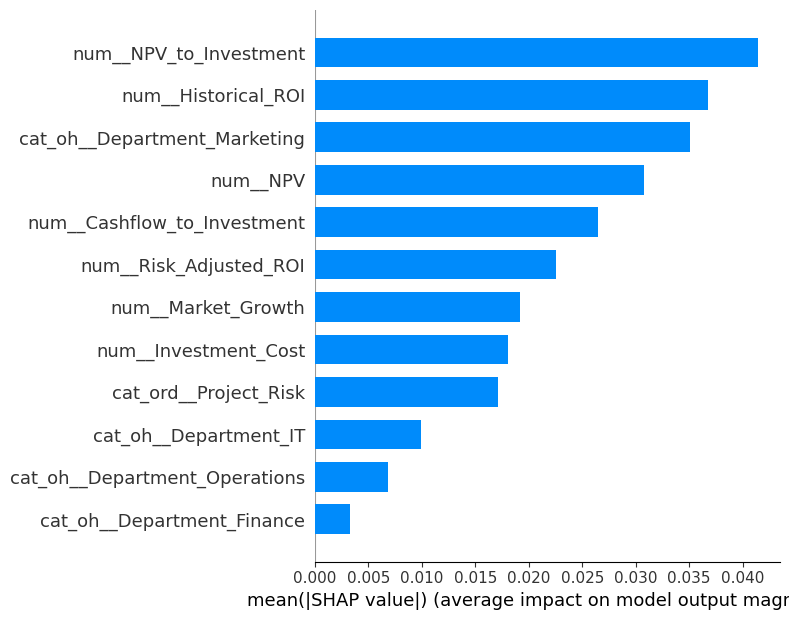

In [39]:
rf_model.fit(X, y)

X_transformed = rf_model.named_steps["preprocessor"].transform(X)
feature_names_shap = rf_model.named_steps["preprocessor"].get_feature_names_out()

print("Transformed shape:", X_transformed.shape)          # should be (50, 12)
print("Feature names:", feature_names_shap.tolist())      # should list all 12
print("Number of features:", len(feature_names_shap))

rf_clf = rf_model.named_steps["classifier"]
explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_transformed)

# shap_values is a list [class0, class1] — pick class 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

print("SHAP values shape:", sv.shape)                     # should be (50, 12)

shap.summary_plot(
    sv,
    X_transformed,
    feature_names=feature_names_shap,
    plot_type="bar",
    show=True
)

In [40]:
def clean_name(name):
    return (name.replace("num__","").replace("cat_oh__","")
                .replace("cat_ord__","").replace("_"," ").title())

clean_names = [clean_name(n) for n in feature_names_shap]

explainer_exp = shap.Explainer(
    rf_model.named_steps["classifier"],
    X_transformed,
    feature_names=clean_names
)
shap_explanation = explainer_exp(X_transformed)

def get_idx(project_id):
    matches = df[df["Project_ID"] == project_id].index.tolist()
    if not matches: raise ValueError(f"Project_ID {project_id} not found.")
    return matches[0]

fund_proj   = ranked_projects[ranked_projects["Recommendation"] == "Fund"].iloc[0]["Project_ID"]
review_proj = ranked_projects[ranked_projects["Recommendation"] == "Review"].iloc[0]["Project_ID"]
reject_proj = ranked_projects[ranked_projects["Recommendation"] == "Reject"].iloc[0]["Project_ID"]

bucket_examples = [
    (fund_proj,   "Fund",   "green"),
    (review_proj, "Review", "orange"),
    (reject_proj, "Reject", "red"),
]

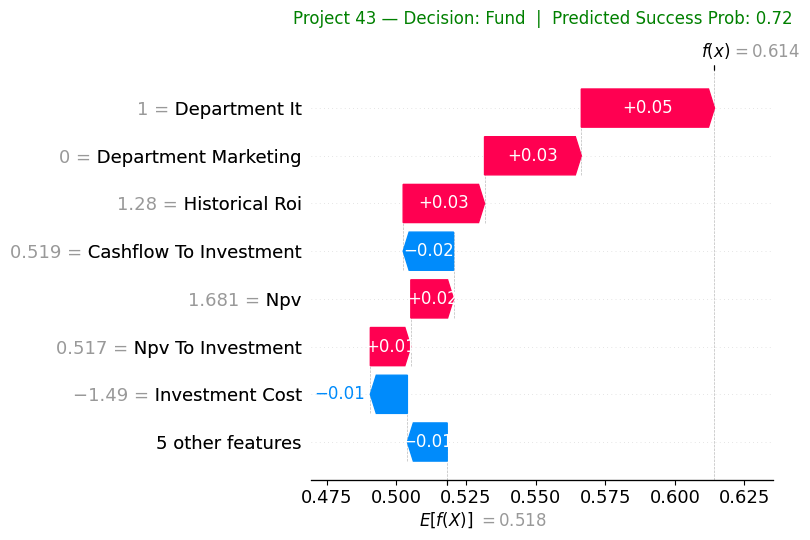

  → Saved: shap_waterfall_proj43_fund.png  (Project 43, Fund, p=0.72)


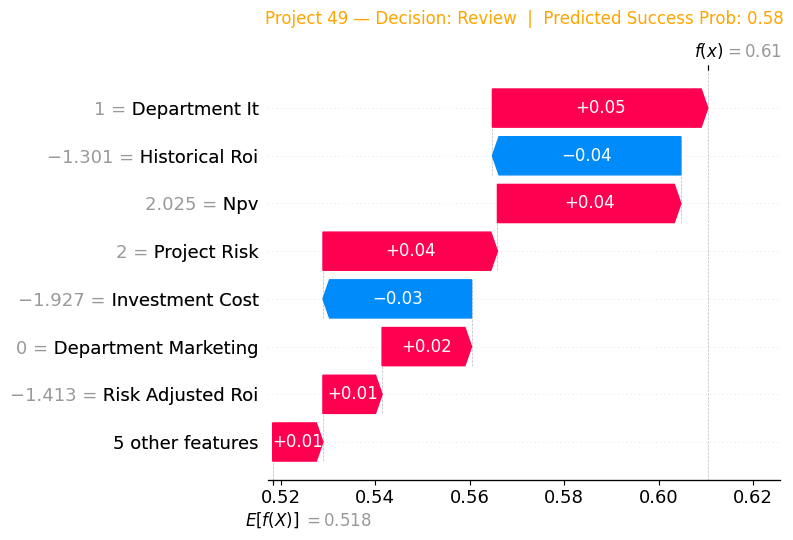

  → Saved: shap_waterfall_proj49_review.png  (Project 49, Review, p=0.58)


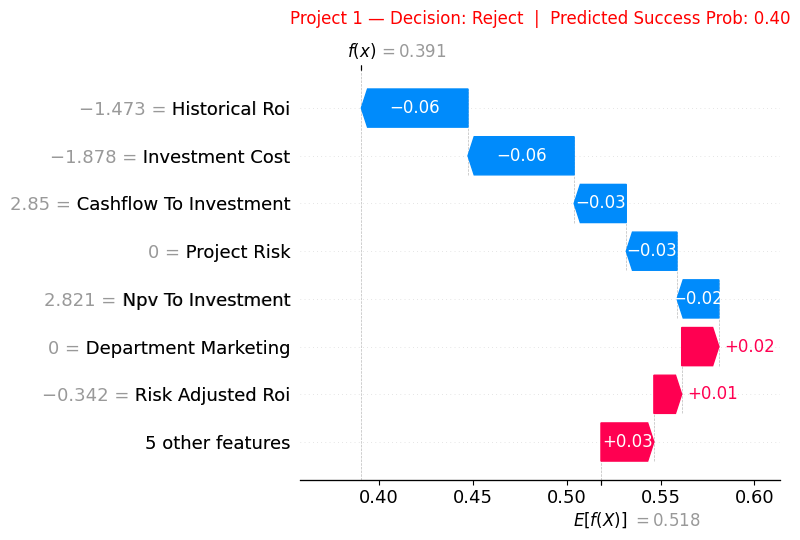

  → Saved: shap_waterfall_proj1_reject.png  (Project 1, Reject, p=0.40)


In [41]:
# unpack for a clean single Explanation

for proj_id, label, color in bucket_examples:
    idx = get_idx(proj_id)
    prob = df.loc[idx, "Predicted_Success_Prob"]

    # Build a clean scalar Explanation for class 1
    exp_single = shap.Explanation(
        values      = shap_explanation[idx].values[:, 1],       # shape (n_features,)
        base_values = float(shap_explanation[idx].base_values[1]),  # scalar
        data        = shap_explanation[idx].data,               # feature values
        feature_names = clean_names
    )

    shap.plots.waterfall(exp_single, max_display=8, show=False)

    plt.title(
        f"Project {int(proj_id)} — Decision: {label}  |  "
        f"Predicted Success Prob: {prob:.2f}",
        fontsize=12, pad=12, color=color
    )
    plt.tight_layout()
    fname = f"shap_waterfall_proj{int(proj_id)}_{label.lower()}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  → Saved: {fname}  (Project {int(proj_id)}, {label}, p={prob:.2f})")

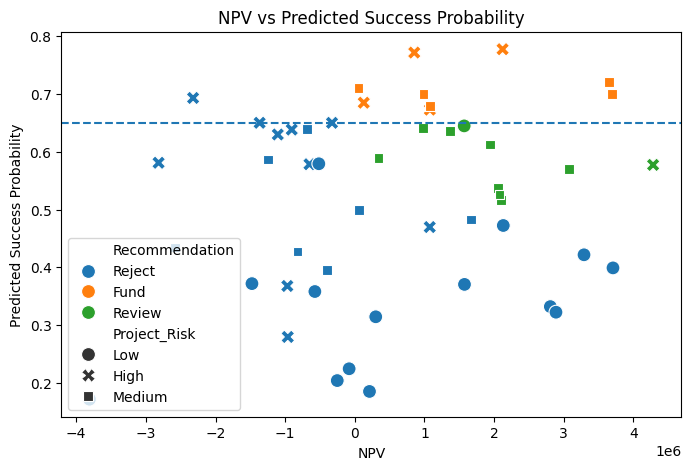

In [42]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="NPV",
    y="Predicted_Success_Prob",
    hue="Recommendation",
    style="Project_Risk",
    s=100
)
plt.axhline(SUCCESS_THRESHOLD, linestyle="--")
plt.title("NPV vs Predicted Success Probability")
plt.xlabel("NPV")
plt.ylabel("Predicted Success Probability")
plt.show()

In [43]:
# with budget constraint assumption of 40% of investment cost
budget = df["Investment_Cost"].sum() * 0.4

selected = ranked_projects[ranked_projects["Recommendation"] == "Fund"].copy()
selected["Cumulative_Investment"] = selected["Investment_Cost"].cumsum()

selected_projects = selected[selected["Cumulative_Investment"] <= budget]

selected_projects[[
    "Rank",
    "Project_ID",
    "Investment_Cost",
    "Expected_Value",
    "Risk_Adjusted_EV",
    "Recommendation",
    "Cumulative_Investment"
]]

,Rank,Project_ID,Investment_Cost,Expected_Value,Risk_Adjusted_EV,Recommendation,Cumulative_Investment
0,1,43,664685,2.635652e+06,1.757102e+06,Fund,664685
1,2,35,296769,2.585661e+06,1.723774e+06,Fund,961454
2,3,3,2516182,1.649361e+06,8.246805e+05,Fund,3477636
3,4,36,2758505,7.325045e+05,4.883363e+05,Fund,6236141
4,5,40,3147262,6.899874e+05,4.599916e+05,Fund,9383403
5,6,10,2670406,7.248561e+05,3.624280e+05,Fund,12053809
6,7,42,2685031,6.586357e+05,3.293178e+05,Fund,14738840
7,8,27,2657489,8.778786e+04,4.389393e+04,Fund,17396329
8,9,11,3516664,3.779962e+04,2.519974e+04,Fund,20912993


In [44]:
fund_df   = ranked_projects[ranked_projects["Recommendation"] == "Fund"]
review_df = ranked_projects[ranked_projects["Recommendation"] == "Review"]
reject_df = ranked_projects[ranked_projects["Recommendation"] == "Reject"]

print("=" * 60)
print("   AURORA CAPITAL ALLOCATION — EXECUTIVE SUMMARY")
print("=" * 60)

print(f"\n{'Total projects evaluated:':<40} {len(df)}")
print(f"{'Projects recommended to Fund:':<40} {len(fund_df)}")
print(f"{'Projects flagged for Review:':<40} {len(review_df)}")
print(f"{'Projects recommended to Reject:':<40} {len(reject_df)}")

total_inv  = fund_df["Investment_Cost"].sum()
total_ev   = fund_df["Expected_Value"].sum()
total_rae  = fund_df["Risk_Adjusted_EV"].sum()
avg_prob   = fund_df["Predicted_Success_Prob"].mean()
avg_irr    = fund_df["IRR"].mean() if "IRR" in fund_df.columns else float("nan")

print(f"\n{'--- FUND-TIER PORTFOLIO ---':}")
print(f"{'Total Investment Required:':<40} {total_inv:>15,.0f}")
print(f"{'Total Expected Value:':<40} {total_ev:>15,.0f}")
print(f"{'Total Risk-Adjusted EV:':<40} {total_rae:>15,.0f}")
print(f"{'Avg. Success Probability:':<40} {avg_prob:>15.2%}")
print(f"{'Avg. IRR:':<40} {avg_irr:>15.2%}")

print("\n--- TOP 5 RECOMMENDED PROJECTS ---")
top5_summary = fund_df[[
    "Rank", "Project_ID", "Department", "Investment_Cost",
    "NPV", "Predicted_Success_Prob", "Risk_Adjusted_EV", "Project_Risk"
]].head(5).copy()

top5_summary["Predicted_Success_Prob"] = top5_summary["Predicted_Success_Prob"].map("{:.1%}".format)
top5_summary["NPV"]              = top5_summary["NPV"].map("{:,.0f}".format)
top5_summary["Investment_Cost"]  = top5_summary["Investment_Cost"].map("{:,.0f}".format)
top5_summary["Risk_Adjusted_EV"] = top5_summary["Risk_Adjusted_EV"].map("{:,.0f}".format)

print(top5_summary.to_string(index=False))

print("\n--- BUDGET-CONSTRAINED SHORTLIST (40% capital budget) ---")
budget = df["Investment_Cost"].sum() * 0.4
budget_df = ranked_projects.copy()
budget_df["Cumulative_Investment"] = budget_df["Investment_Cost"].cumsum()
shortlist = budget_df[budget_df["Cumulative_Investment"] <= budget]
print(f"Budget ceiling : {budget:,.0f}")
print(f"Projects within budget : {len(shortlist)}")
print(f"Total EV of shortlist  : {shortlist['Expected_Value'].sum():,.0f}")
print(shortlist[["Project_ID", "Department", "Investment_Cost", "Recommendation"]].to_string(index=False))

   AURORA CAPITAL ALLOCATION — EXECUTIVE SUMMARY

Total projects evaluated:                50
Projects recommended to Fund:            9
Projects flagged for Review:             10
Projects recommended to Reject:          31

--- FUND-TIER PORTFOLIO ---
Total Investment Required:                    20,912,993
Total Expected Value:                          9,802,245
Total Risk-Adjusted EV:                        6,014,723
Avg. Success Probability:                         71.31%
Avg. IRR:                                        110.78%

--- TOP 5 RECOMMENDED PROJECTS ---
 Rank  Project_ID Department Investment_Cost       NPV Predicted_Success_Prob Risk_Adjusted_EV Project_Risk
    1          43         IT         664,685 3,653,868                  72.1%        1,757,102       Medium
    2          35         IT         296,769 3,690,876                  70.1%        1,723,774       Medium
    3           3    Finance       2,516,182 2,121,152                  77.8%          824,680       

In [45]:
executive_table = ranked_projects[[
    "Rank",
    "Project_ID",
    "Department",
    "Investment_Cost",
    "NPV",
    "IRR",
    "Predicted_Success_Prob",
    "Expected_Value",
    "Risk_Adjusted_EV",
    "Recommendation"
]].copy()

executive_table["Predicted_Success_Prob"] = executive_table["Predicted_Success_Prob"].round(3)
executive_table["NPV"] = executive_table["NPV"].round(0)
executive_table["IRR"] = executive_table["IRR"].round(3)
executive_table["Expected_Value"] = executive_table["Expected_Value"].round(0)
executive_table["Risk_Adjusted_EV"] = executive_table["Risk_Adjusted_EV"].round(0)

executive_table.head(15)

,Rank,Project_ID,Department,Investment_Cost,NPV,IRR,Predicted_Success_Prob,Expected_Value,Risk_Adjusted_EV,Recommendation
0,1,43,IT,664685,3653868.0,1.964,0.721,2635652.0,1757102.0,Fund
1,2,35,IT,296769,3690876.0,6.157,0.701,2585661.0,1723774.0,Fund
2,3,3,Finance,2516182,2121152.0,0.491,0.778,1649361.0,824680.0,Fund
3,4,36,Finance,2758505,1079105.0,0.315,0.679,732505.0,488336.0,Fund
4,5,40,Operations,3147262,985981.0,0.264,0.700,689987.0,459992.0,Fund
5,6,10,IT,2670406,1077058.0,0.313,0.673,724856.0,362428.0,Fund
6,7,42,Operations,2685031,853386.0,0.234,0.772,658636.0,329318.0,Fund
7,8,27,IT,2657489,128161.0,0.121,0.685,87788.0,43894.0,Fund
8,9,11,Operations,3516664,53253.0,0.110,0.710,37800.0,25200.0,Fund
9,10,49,IT,123247,4281887.0,11.448,0.577,2472002.0,1236001.0,Review


In [46]:
def generate_summary(row):
    # Logic based strictly on financial metrics and raw data
    roi = row['Forecasted_ROI']
    npv = row['NPV']
    risk = row['Project_Risk']
    rec = row['Recommendation']

    if rec == 'Fund':
        summary = f"High-priority investment. This project demonstrates strong financial health with an NPV of ${npv:,.0f} and an estimated ROI of {roi:.1%}. Despite {risk} risk, the returns justify the capital allocation."
    elif rec == 'Review':
        summary = f"Strategic hold. While the project is financially viable (NPV: ${npv:,.0f}), the {risk} risk profile suggests we should review dependencies or wait for a more favorable budget window."
    else:
        if npv < 0:
            summary = f"Financial Reject. The project is estimated to lose ${abs(npv):,.0f} in present value terms. The projected cash flows do not recover the initial investment cost."
        else:
            summary = f"Risk/Reward Mismatch. Although the NPV is slightly positive, the {risk} risk level and low ROI ({roi:.1%}) make this a lower priority compared to other available opportunities."
    return summary

# Re-apply the logic to the table
executive_table = ranked_projects[[
    'Rank',
    'Project_ID',
    'Department',
    'Investment_Cost',
    'NPV',
    'IRR',
    'Forecasted_ROI',
    'Project_Risk',
    'Recommendation'
]].copy()

executive_table['Executive_Summary'] = executive_table.apply(generate_summary, axis=1)

# Display the heuristic-based results
display(executive_table[['Rank', 'Project_ID', 'Recommendation', 'Executive_Summary']].head(10))

,Rank,Project_ID,Recommendation,Executive_Summary
0,1,43,Fund,High-priority investment. This project demonst...
1,2,35,Fund,High-priority investment. This project demonst...
2,3,3,Fund,High-priority investment. This project demonst...
3,4,36,Fund,High-priority investment. This project demonst...
4,5,40,Fund,High-priority investment. This project demonst...
5,6,10,Fund,High-priority investment. This project demonst...
6,7,42,Fund,High-priority investment. This project demonst...
7,8,27,Fund,High-priority investment. This project demonst...
8,9,11,Fund,High-priority investment. This project demonst...
9,10,49,Review,Strategic hold. While the project is financial...


In [47]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import base64
import numpy as np
from IPython.display import HTML, display

# 1. Data Preparation
df_dash = executive_table.copy()

# Updated Table Helper: Removed 'Predicted_Success_Prob' as it is no longer in the dataframe
def create_html_table(df):
    # Define specific columns to show in the UI table for clarity
    display_cols = ['Rank', 'Project_ID', 'Department', 'Investment_Cost', 'NPV', 'IRR', 'Recommendation', 'Executive_Summary']
    html = f'''
    <div style="height:450px; overflow-y:auto; border:1px solid #dcdcdc; font-family: sans-serif; font-size:11px; margin-top:10px; color: black;">
        <table style="width:100%; border-collapse: collapse; color: black;">
            <tr style="background-color: #1a237e; color: white; position: sticky; top: 0;">
                {''.join([f'<th style="padding:12px; border: 1px solid #ddd;">{c.replace("_", " ")}</th>' for c in display_cols])}
            </tr>
    '''
    for _, row in df.iterrows():
        bg_color = '#e8f5e9' if row['Recommendation'] == 'Fund' else '#fff3e0' if row['Recommendation'] == 'Review' else '#ffebee'
        html += f'<tr style="background-color: {bg_color}; border-bottom: 1px solid #eee;">'
        for c in display_cols:
            val = row[c]
            if c == 'Executive_Summary':
                html += f'<td style="padding:10px; text-align:left; border: 1px solid #ddd; color: black; font-weight: 500;">{val}</td>'
            else:
                formatted_val = f"{val:,.0f}" if isinstance(val, (int, float, np.integer, np.floating)) and not any(x in c for x in ['Prob', 'IRR', 'ROI']) else f"{val:.1%}" if any(x in c for x in ['Prob', 'IRR', 'ROI']) and isinstance(val, (float, np.floating)) else val
                html += f'<td style="padding:8px; text-align:center; border: 1px solid #ddd; color: black;">{formatted_val}</td>'
        html += '</tr>'
    html += "</table></div>"
    return html

# 2. Create Figure
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'indicator', 'colspan': 2}, None],
           [{'type': 'bar'}, {'type': 'pie'}]],
    vertical_spacing=0.25
)

recs = ['All', 'Fund', 'Review', 'Reject']
buttons = []
num_traces_per_rec = 5

for i, rec in enumerate(recs):
    visible = (rec == 'All')
    dff = df_dash if rec == 'All' else df_dash[df_dash['Recommendation'] == rec]

    fig.add_trace(go.Indicator(
        mode="number", value=dff['Investment_Cost'].sum(),
        title={'text': "Total Capex", 'font': {'size': 19}},
        number={'prefix': "$", 'valueformat': ",.2s", 'font': {'size': 35}},
        domain={'x': [0, 0.3], 'y': [0.7, 1]}, visible=visible
    ))
    fig.add_trace(go.Indicator(
        mode="number", value=dff['NPV'].sum(),
        title={'text': "Portfolio NPV", 'font': {'size': 19}},
        number={'prefix': "$", 'valueformat': ",.2s", 'font': {'size': 35, 'color': '#1a237e'}},
        domain={'x': [0.35, 0.65], 'y': [0.7, 1]}, visible=visible
    ))
    fig.add_trace(go.Indicator(
        mode="number", value=dff['IRR'].mean()*100 if len(dff)>0 else 0,
        title={'text': "Avg IRR", 'font': {'size': 19}},
        number={'suffix': "%", 'valueformat': ".1f", 'font': {'size': 35}},
        domain={'x': [0.7, 1], 'y': [0.7, 1]}, visible=visible
    ))

    fig.add_trace(go.Bar(
        x=dff['Project_ID'].astype(str), y=dff['IRR']*100,
        marker_color='#283593', visible=visible,
        customdata=dff['Rank'],
        hovertemplate="Project ID: %{x}<br>Rank: %{customdata}<br>IRR: %{y:.1f}%<extra></extra>"
    ), row=2, col=1)

    dept_sums = dff.groupby('Department')['Investment_Cost'].sum()
    fig.add_trace(go.Pie(
        labels=dept_sums.index, values=dept_sums.values,
        hole=0.4, marker_colors=['#1a237e', '#3949ab', '#7986cb', '#c5cae9'],
        textinfo='label+percent', visible=visible, showlegend=False
    ), row=2, col=2)

    visibility = [False] * (len(recs) * num_traces_per_rec)
    visibility[i*num_traces_per_rec : (i+1)*num_traces_per_rec] = [True] * num_traces_per_rec

    buttons.append(dict(
        label=rec, method="update",
        args=[{"visible": visibility},
              {"annotations[0].text": f"Top Projects to Filter: {rec}"}]
    ))

fig.update_layout(
    height=750, margin=dict(t=150, b=100, l=40, r=40),
    template="plotly_white",
    showlegend=False,
    updatemenus=[dict(buttons=buttons, direction="down", x=1.0, xanchor="right", y=1.20, showactive=True)],
    title={'text': "AURORA FINANCE CAPITAL ALLOCATION", 'x': 0.5, 'xanchor': 'center', 'font': {'size': 22, 'color': '#1a237e'}},
    annotations=[
        dict(text="Top Projects to Filter:", x=0.5, y=1.12, xref="paper", yref="paper", showarrow=False, font=dict(size=14, color="#666"), xanchor="center"),
        dict(text="IRR % by Project ID", x=0.22, y=-0.12, xref="paper", yref="paper", showarrow=False, font=dict(size=15, color="#333"), xanchor="center"),
        dict(text="Investment Cost($) by Department", x=0.82, y=-0.12, xref="paper", yref="paper", showarrow=False, font=dict(size=15, color="#333"), xanchor="center")
    ]
)

csv_data = df_dash.to_csv(index=False)
b64 = base64.b64encode(csv_data.encode()).decode()
download_btn = f'<a href="data:file/csv;base64,{b64}" download="aurora_allocation_data.csv" style="display:inline-block; margin:20px 0; padding:12px 24px; background-color:#1a237e; color:white; text-decoration:none; border-radius:4px; font-family:sans-serif; font-size:14px; font-weight:bold;">📥 Download Full Data with Summaries (CSV)</a>'

dashboard_html = fig.to_html(full_html=False, include_plotlyjs='cdn')

final_layout = f'''
<div style="background-color: #f8f9fa; padding: 20px; border-radius: 8px; font-family: sans-serif;">
    <div style="background: white; border-radius: 5px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); margin-bottom: 20px;">
        {dashboard_html}
    </div>
    <div style="background: white; padding: 20px; border-radius: 5px; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
        <h3 style="margin-top:0; color:#1a237e; border-bottom: 2px solid #1a237e; padding-bottom: 10px;">Strategic Project Details & Executive Summaries</h3>
        {create_html_table(df_dash)}
        <div style="text-align: right;">{download_btn}</div>
    </div>
</div>
'''
display(HTML(final_layout))

ModuleNotFoundError: No module named 'plotly'

In [50]:
# @title 📊 Aurora Finance Capital Allocation Dashboard {display-mode: "form"}

import pandas as pd
import json
from IPython.display import HTML
# from google.colab import output

# Prepare data from the kernel state
df_dash = executive_table.copy()
# Ensure we have the EV/RAEV data from ranked_projects for the valuation chart
full_data = ranked_projects[['Project_ID', 'Expected_Value', 'Risk_Adjusted_EV']].copy()
df_merged = df_dash.merge(full_data, on='Project_ID', how='left')

# Convert to JSON for injection
projects_json = df_merged.to_json(orient='records')

def _report_js_error(message):
    print(f"JavaScript Error: {message}")

# output.register_callback('report_js_error', _report_js_error)

html_code = """
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f4f6f8; margin: 0; padding: 20px; color: #333; }
        .dashboard-container { display: flex; flex-direction: column; gap: 20px; }
        .controls { background: white; padding: 15px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); display: flex; align-items: center; gap: 15px; }
        .kpi-row { display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 20px; }
        .kpi-card { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); text-align: center; }
        .kpi-value { font-size: 24px; font-weight: bold; color: #1a237e; margin: 10px 0; }
        .kpi-label { font-size: 14px; color: #666; text-transform: uppercase; }
        .chart-row { display: grid; grid-template-columns: 2fr 1fr; gap: 20px; }
        .valuation-row { display: grid; grid-template-columns: 1fr; gap: 20px; }
        .card { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); display: flex; flex-direction: column; min-height: 350px; }
        .card h3 { margin-top: 0; font-size: 16px; color: #1a237e; border-bottom: 1px solid #eee; padding-bottom: 10px; }
        .canvas-wrapper { position: relative; flex-grow: 1; min-height: 0; }
        .table-container { background: white; padding: 20px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); overflow-x: auto; }
        table { width: 100%; border-collapse: collapse; margin-top: 10px; font-size: 13px; }
        th { background: #1a237e; color: white; text-align: left; padding: 12px; position: sticky; top: 0; }
        td { padding: 10px; border-bottom: 1px solid #eee; }
        .rec-fund { color: #2e7d32; font-weight: bold; }
        .rec-review { color: #ef6c00; font-weight: bold; }
        .rec-reject { color: #c62828; font-weight: bold; }
        select { padding: 8px; border-radius: 4px; border: 1px solid #ddd; outline: none; }
    </style>
</head>
<body>
    <div class="dashboard-container">
        <div class="controls">
            <label style="font-weight:bold">Strategic Filter:</label>
            <select id="recFilter" onchange="updateDashboard()">
                <option value="All">All Projects</option>
                <option value="Fund">Fund Only</option>
                <option value="Review">Review Required</option>
                <option value="Reject">Rejected</option>
            </select>
        </div>

        <div class="kpi-row">
            <div class="kpi-card"><div class="kpi-label">Total Capex</div><div id="kpi-capex" class="kpi-value">$0</div></div>
            <div class="kpi-card"><div class="kpi-label">Portfolio NPV</div><div id="kpi-npv" class="kpi-value">$0</div></div>
            <div class="kpi-card"><div class="kpi-label">Avg IRR</div><div id="kpi-irr" class="kpi-value">0%</div></div>
            <div class="kpi-card"><div class="kpi-label">Project Count</div><div id="kpi-count" class="kpi-value">0</div></div>
        </div>

        <div class="chart-row">
            <div class="card">
                <h3>IRR Performance by Project</h3>
                <div class="canvas-wrapper"><canvas id="irrChart"></canvas></div>
            </div>
            <div class="card">
                <h3>Capex by Department</h3>
                <div class="canvas-wrapper"><canvas id="deptChart"></canvas></div>
            </div>
        </div>

        <div class="valuation-row">
            <div class="card">
                <h3>Valuation Subplot: Expected Value vs Risk-Adjusted EV</h3>
                <div class="canvas-wrapper"><canvas id="valChart"></canvas></div>
            </div>
        </div>

        <div class="table-container">
            <h3 style="color:#1a237e; margin-top:0">Project Summary & Heuristics</h3>
            <table id="projectTable">
                <thead>
                    <tr>
                        <th>Rank</th><th>ID</th><th>Dept</th><th>Capex</th><th>NPV</th><th>IRR</th><th>Decision</th><th>Summary</th>
                    </tr>
                </thead>
                <tbody></tbody>
            </table>
        </div>
    </div>

    <script>
        window.onerror = function(message) {
            google.colab.kernel.invokeFunction('report_js_error', [message], {});
        };

        const rawData = DATA_PLACEHOLDER;
        let irrChart, deptChart, valChart;

        function formatCurrency(val) {
            return new Intl.NumberFormat('en-US', { style: 'currency', currency: 'USD', maximumFractionDigits: 0 }).format(val);
        }

        function initCharts() {
            const ctxIrr = document.getElementById('irrChart').getContext('2d');
            irrChart = new Chart(ctxIrr, {
                type: 'bar',
                data: { labels: [], datasets: [{ label: 'IRR %', data: [], backgroundColor: '#3949ab' }] },
                options: { responsive: true, maintainAspectRatio: false, scales: { y: { beginAtZero: true, ticks: { callback: v => v + '%' } } } }
            });

            const ctxDept = document.getElementById('deptChart').getContext('2d');
            deptChart = new Chart(ctxDept, {
                type: 'doughnut',
                data: { labels: [], datasets: [{ data: [], backgroundColor: ['#1a237e', '#3949ab', '#7986cb', '#c5cae9'] }] },
                options: { responsive: true, maintainAspectRatio: false, plugins: { legend: { position: 'bottom' } } }
            });

            const ctxVal = document.getElementById('valChart').getContext('2d');
            valChart = new Chart(ctxVal, {
                type: 'bar',
                data: { labels: [], datasets: [
                    { label: 'Expected Value', data: [], backgroundColor: '#3949ab' },
                    { label: 'Risk-Adjusted EV', data: [], backgroundColor: '#ef5350' }
                ] },
                options: { responsive: true, maintainAspectRatio: false, scales: { y: { beginAtZero: true } } }
            });
        }

        function updateDashboard() {
            const filter = document.getElementById('recFilter').value;
            const filtered = filter === 'All' ? rawData : rawData.filter(d => d.Recommendation === filter);

            // Update KPIs
            const totalCapex = filtered.reduce((a, b) => a + b.Investment_Cost, 0);
            const totalNpv = filtered.reduce((a, b) => a + b.NPV, 0);
            const avgIrr = filtered.length ? (filtered.reduce((a, b) => a + b.IRR, 0) / filtered.length) * 100 : 0;

            document.getElementById('kpi-capex').innerText = formatCurrency(totalCapex);
            document.getElementById('kpi-npv').innerText = formatCurrency(totalNpv);
            document.getElementById('kpi-irr').innerText = avgIrr.toFixed(1) + '%';
            document.getElementById('kpi-count').innerText = filtered.length;

            // Update Charts
            irrChart.data.labels = filtered.map(d => 'P' + d.Project_ID);
            irrChart.data.datasets[0].data = filtered.map(d => (d.IRR * 100).toFixed(2));
            irrChart.update();

            const depts = [...new Set(filtered.map(d => d.Department))];
            deptChart.data.labels = depts;
            deptChart.data.datasets[0].data = depts.map(dept => filtered.filter(d => d.Department === dept).reduce((a, b) => a + b.Investment_Cost, 0));
            deptChart.update();

            valChart.data.labels = filtered.map(d => 'P' + d.Project_ID);
            valChart.data.datasets[0].data = filtered.map(d => d.Expected_Value);
            valChart.data.datasets[1].data = filtered.map(d => d.Risk_Adjusted_EV);
            valChart.update();

            // Update Table
            const tbody = document.querySelector('#projectTable tbody');
            tbody.innerHTML = '';
            filtered.forEach(d => {
                const row = `<tr>
                    <td>${d.Rank}</td>
                    <td>${d.Project_ID}</td>
                    <td>${d.Department}</td>
                    <td>${formatCurrency(d.Investment_Cost)}</td>
                    <td>${formatCurrency(d.NPV)}</td>
                    <td>${(d.IRR * 100).toFixed(1)}%</td>
                    <td class="rec-${d.Recommendation.toLowerCase()}">${d.Recommendation}</td>
                    <td style="font-size:11px; max-width:300px">${d.Executive_Summary}</td>
                </tr>`;
                tbody.innerHTML += row;
            });
        }

        initCharts();
        updateDashboard();
    </script>
</body>
</html>
""".replace('DATA_PLACEHOLDER', projects_json)

display(HTML(html_code))


Rank,ID,Dept,Capex,NPV,IRR,Decision,Summary
